In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import pandas as pd

sns.set_theme(style="whitegrid")

In [56]:
batch_size = 64
epochs = 5
learning_rate = 0.001
hidden1 = 128
hidden2 = 64

activations_to_test = ['relu', 'sigmoid', 'tanh']
optimizers_to_test = ['sgd', 'adam']
loss_functions_to_test = ['cross_entropy', 'nll']

In [57]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


def get_activation(name):
    if name == 'relu':
        return nn.ReLU()
    elif name == 'sigmoid':
        return nn.Sigmoid()
    elif name == 'tanh':
        return nn.Tanh()
    else:
        raise ValueError("Unknown activation")

In [58]:
class MLP(nn.Module):
    def __init__(self, activation, use_log_softmax=False):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, hidden1)
        self.act1 = activation
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.act2 = activation
        self.fc3 = nn.Linear(hidden2, 10)
        self.use_log_softmax = use_log_softmax
        self.log_softmax = nn.LogSoftmax(dim=1)
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        x = self.fc3(x)
        if self.use_log_softmax:
            x = self.log_softmax(x)
        return x

In [59]:
def get_criterion(loss_name):
    if loss_name == 'cross_entropy':
        return nn.CrossEntropyLoss()
    elif loss_name == 'nll':
        return nn.NLLLoss()
    else:
        raise ValueError(f"Unknown loss: {loss_name}")

def get_optimizer(optimizer_name, model_params, lr):
    if optimizer_name.lower() == 'sgd':
        return optim.SGD(model_params, lr=lr)
    elif optimizer_name.lower() == 'adam':
        return optim.Adam(model_params, lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

In [60]:
def train_model(model, train_loader, criterion, optimizer, epochs, test_loader=None):
    train_losses = []
    train_accuracies = []
    test_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        all_preds = []
        all_labels = []
        
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds)
            all_labels.append(labels)
        
        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        train_acc = (all_preds == all_labels).float().mean().item()
        
        train_losses.append(running_loss / len(train_loader.dataset))
        train_accuracies.append(train_acc)
        
        if test_loader is not None:
            test_acc = evaluate_model(model, test_loader)['accuracy']
            test_accuracies.append(test_acc)
            print(f"Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")
        else:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f}")
    
    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies
    }

def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds)
            all_labels.append(labels)
    
    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1_score': f1,
        'predictions': all_preds,
        'labels': all_labels
    }

In [61]:
results = []

for activation_name in activations_to_test:
    for optimizer_name in optimizers_to_test:
        for loss_name in loss_functions_to_test:
            print(f"Эксперимент: Activation={activation_name.upper()}, Optimizer={optimizer_name.upper()}, Loss={loss_name.upper()}")
            
            activation = get_activation(activation_name)
            use_log_softmax = (loss_name == 'nll')
            model = MLP(activation, use_log_softmax=use_log_softmax)
            
            optimizer = get_optimizer(optimizer_name, model.parameters(), learning_rate)
            criterion = get_criterion(loss_name)
            
            training_history = train_model(model, train_loader, criterion, optimizer, epochs, test_loader)
            
            train_metrics = evaluate_model(model, train_loader)
            test_metrics = evaluate_model(model, test_loader)
            
            print(f"\nФинал:")
            print(f"Train - Accuracy: {train_metrics['accuracy']:.4f}, F1-Score: {train_metrics['f1_score']:.4f}")
            print(f"Test  - Accuracy: {test_metrics['accuracy']:.4f}, F1-Score: {test_metrics['f1_score']:.4f}")
            
            results.append({
                'activation': activation_name,
                'optimizer': optimizer_name,
                'loss_function': loss_name,
                'train_accuracy': train_metrics['accuracy'],
                'train_f1': train_metrics['f1_score'],
                'test_accuracy': test_metrics['accuracy'],
                'test_f1': test_metrics['f1_score'],
                'history': training_history,
                'model': model,
                'test_predictions': test_metrics['predictions'],
                'test_labels': test_metrics['labels']
            })


Эксперимент: Activation=RELU, Optimizer=SGD, Loss=CROSS_ENTROPY
Epoch 1/5 - Loss: 2.2903, Train Acc: 0.0992, Test Acc: 0.0993
Epoch 2/5 - Loss: 2.2593, Train Acc: 0.1724, Test Acc: 0.2872
Epoch 3/5 - Loss: 2.2089, Train Acc: 0.4146, Test Acc: 0.5184
Epoch 4/5 - Loss: 2.1243, Train Acc: 0.5634, Test Acc: 0.6121
Epoch 5/5 - Loss: 1.9845, Train Acc: 0.6184, Test Acc: 0.6359

Финал:
Train - Accuracy: 0.6261, F1-Score: 0.5582
Test  - Accuracy: 0.6359, F1-Score: 0.5689
Эксперимент: Activation=RELU, Optimizer=SGD, Loss=NLL
Epoch 1/5 - Loss: 2.2902, Train Acc: 0.2111, Test Acc: 0.3161
Epoch 2/5 - Loss: 2.2552, Train Acc: 0.3334, Test Acc: 0.3587
Epoch 3/5 - Loss: 2.2021, Train Acc: 0.3802, Test Acc: 0.4245
Epoch 4/5 - Loss: 2.1153, Train Acc: 0.4462, Test Acc: 0.5015
Epoch 5/5 - Loss: 1.9784, Train Acc: 0.5289, Test Acc: 0.5811

Финал:
Train - Accuracy: 0.5693, F1-Score: 0.5137
Test  - Accuracy: 0.5811, F1-Score: 0.5268
Эксперимент: Activation=RELU, Optimizer=ADAM, Loss=CROSS_ENTROPY
Epoch 1/5

In [62]:
results_df = pd.DataFrame([{
    'Activation': r['activation'].upper(),
    'Optimizer': r['optimizer'].upper(),
    'Loss Function': r['loss_function'].upper(),
    'Train Accuracy': f"{r['train_accuracy']:.4f}",
    'Train F1': f"{r['train_f1']:.4f}",
    'Test Accuracy': f"{r['test_accuracy']:.4f}",
    'Test F1': f"{r['test_f1']:.4f}"
} for r in results])

print(results_df.to_string(index=False))

best_result = max(results, key=lambda x: x['test_f1'])
print(f"\n ЛУЧШАЯ МОДЕЛЬ:")
print(f"   Activation: {best_result['activation'].upper()}")
print(f"   Optimizer: {best_result['optimizer'].upper()}")
print(f"   Loss Function: {best_result['loss_function'].upper()}")
print(f"   Test Accuracy: {best_result['test_accuracy']:.4f}")
print(f"   Test F1-Score: {best_result['test_f1']:.4f}")

Activation Optimizer Loss Function Train Accuracy Train F1 Test Accuracy Test F1
      RELU       SGD CROSS_ENTROPY         0.6261   0.5582        0.6359  0.5689
      RELU       SGD           NLL         0.5693   0.5137        0.5811  0.5268
      RELU      ADAM CROSS_ENTROPY         0.9852   0.9852        0.9721  0.9721
      RELU      ADAM           NLL         0.9886   0.9886        0.9767  0.9767
   SIGMOID       SGD CROSS_ENTROPY         0.1124   0.0227        0.1135  0.0231
   SIGMOID       SGD           NLL         0.1124   0.0227        0.1135  0.0231
   SIGMOID      ADAM CROSS_ENTROPY         0.9773   0.9773        0.9669  0.9669
   SIGMOID      ADAM           NLL         0.9782   0.9782        0.9688  0.9688
      TANH       SGD CROSS_ENTROPY         0.6996   0.6599        0.7043  0.6660
      TANH       SGD           NLL         0.7043   0.6692        0.7172  0.6838
      TANH      ADAM CROSS_ENTROPY         0.9896   0.9895        0.9756  0.9756
      TANH      ADAM        

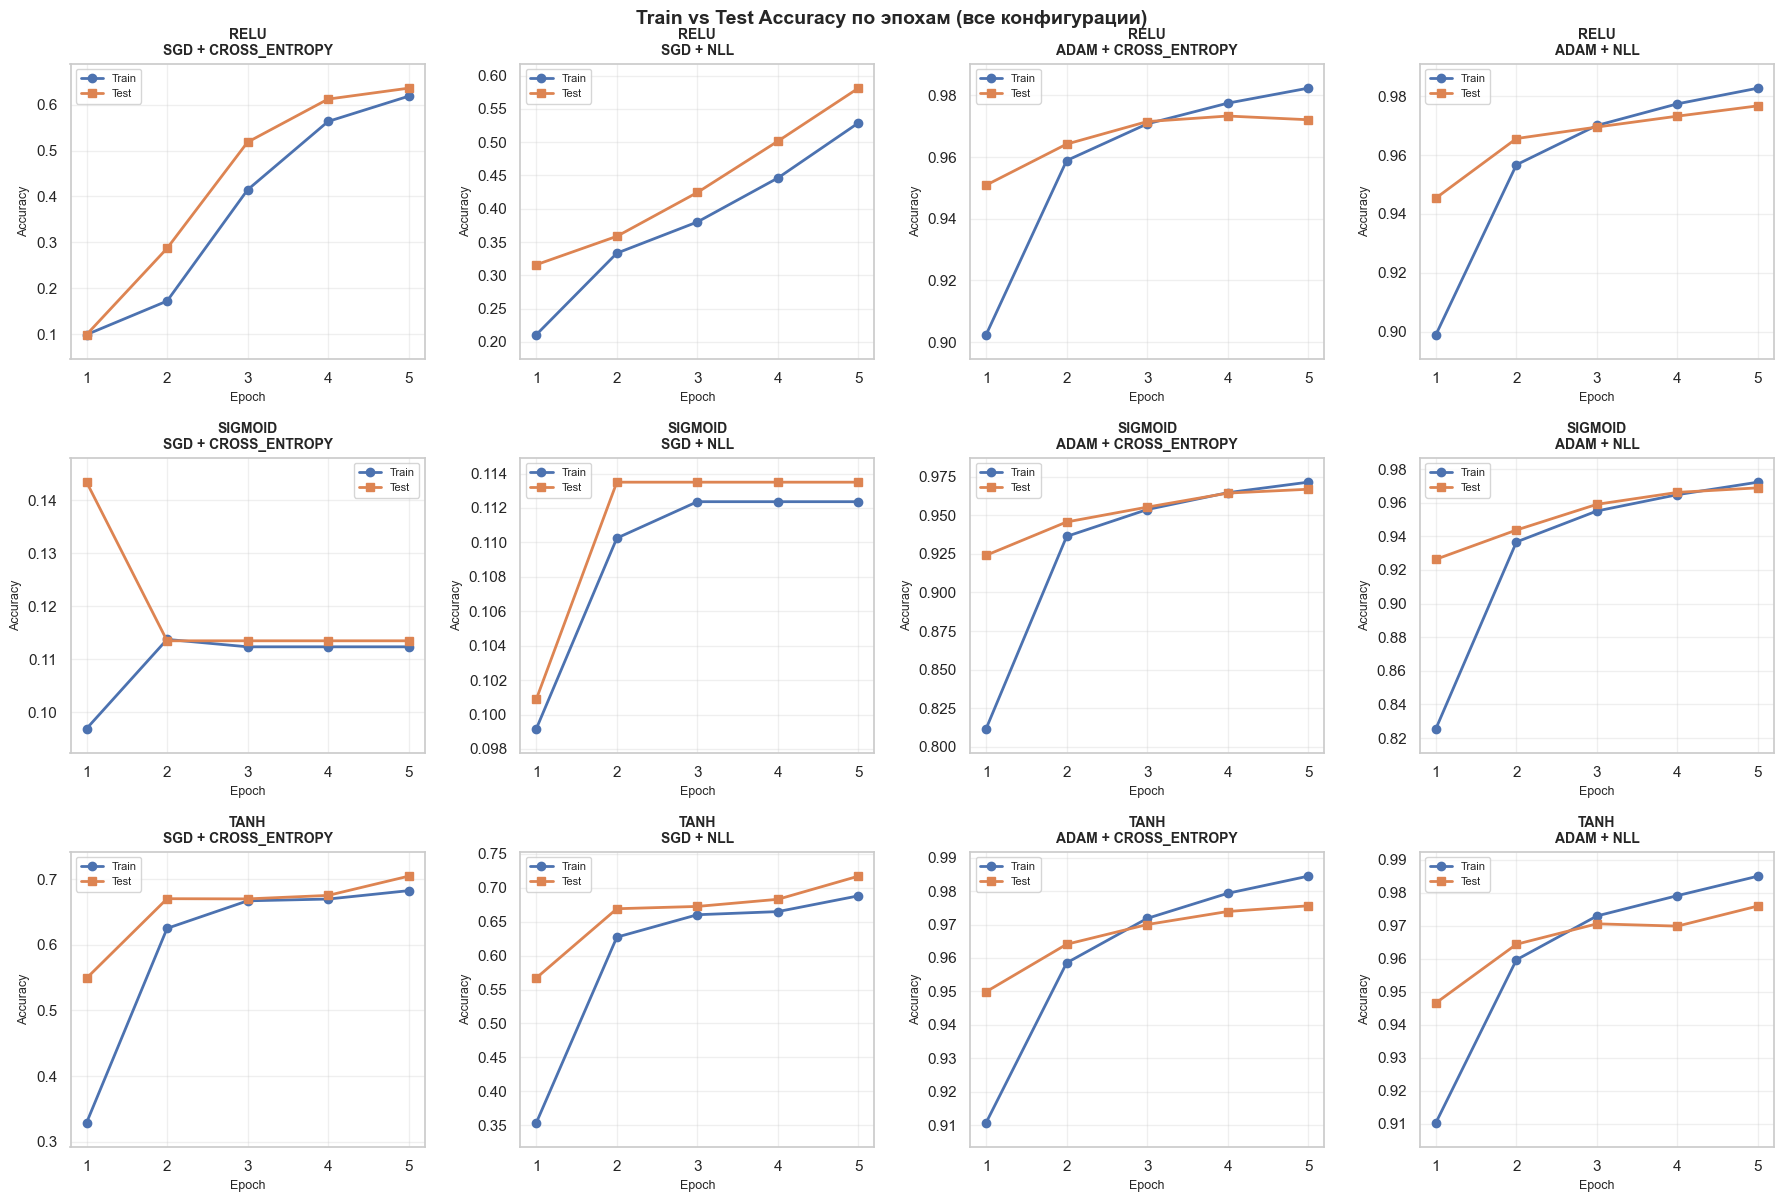

In [63]:
num_experiments = len(results)
ncols = 4
nrows = (num_experiments + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))

if nrows == 1 and ncols == 1:
    axes = [axes]
elif nrows == 1 or ncols == 1:
    axes = axes.flatten()
else:
    axes = axes.flatten()

for idx, result in enumerate(results):
    ax = axes[idx]
    history = result['history']
    epochs_range = range(1, len(history['train_accuracies']) + 1)
    
    ax.plot(epochs_range, history['train_accuracies'], marker='o', label='Train', linewidth=2)
    
    if history['test_accuracies'] and len(history['test_accuracies']) > 0:
        ax.plot(epochs_range, history['test_accuracies'], marker='s', label='Test', linewidth=2)
    
    title = f"{result['activation'].upper()}\n{result['optimizer'].upper()} + {result['loss_function'].upper()}"
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Accuracy', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    all_values = history['train_accuracies'][:]
    if history['test_accuracies']:
        all_values.extend(history['test_accuracies'])
    
    if all_values:
        min_val = min(all_values)
        max_val = max(all_values)
        margin = (max_val - min_val) * 0.1 if max_val > min_val else 0.05
        ax.set_ylim([max(0, min_val - margin), min(1.0, max_val + margin)])

for idx in range(num_experiments, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Train vs Test Accuracy по эпохам (все конфигурации)', fontsize=14, fontweight='bold', y=1.0)
plt.show()

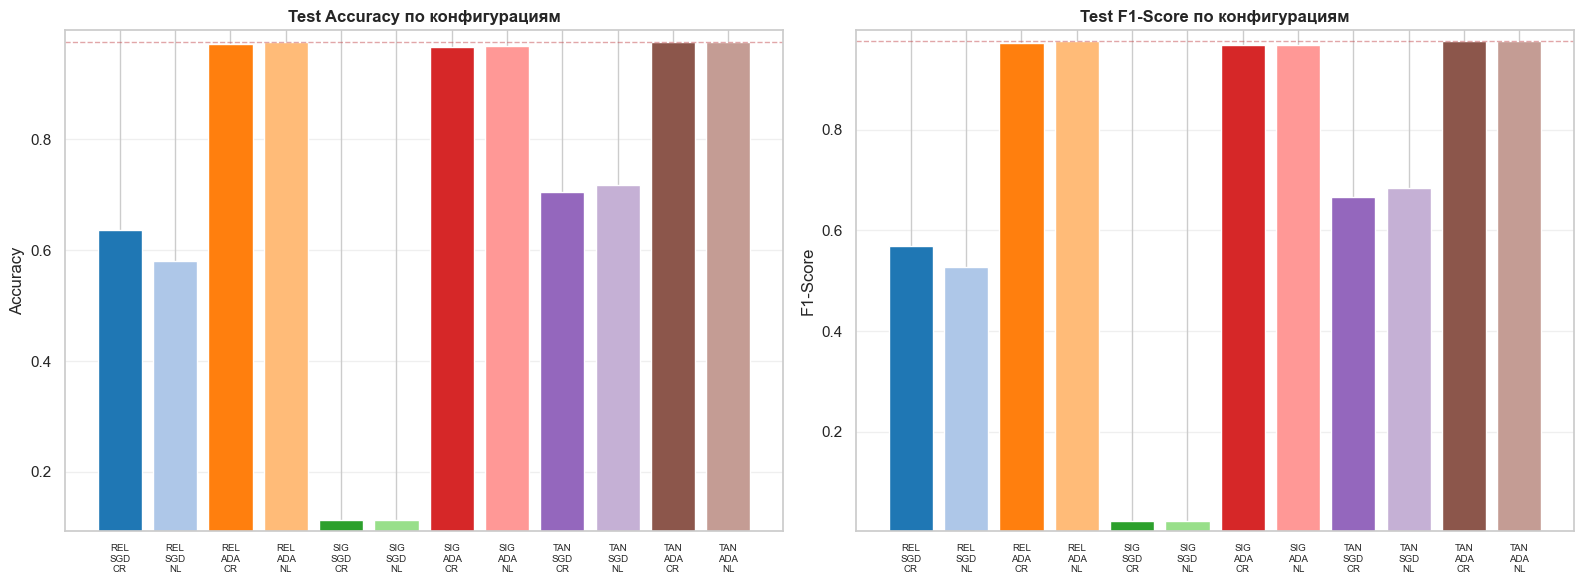

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_labels = [f"{r['activation'][:3].upper()}\n{r['optimizer'][:3].upper()}\n{r['loss_function'][:2].upper()}" 
            for r in results]
test_accuracies = [r['test_accuracy'] for r in results]
test_f1_scores = [r['test_f1'] for r in results]

bars1 = axes[0].bar(range(len(results)), test_accuracies, 
                     color=plt.cm.tab20(range(len(results))))
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Test Accuracy по конфигурациям', fontweight='bold', fontsize=12)
axes[0].set_xticks(range(len(results)))
axes[0].set_xticklabels(x_labels, fontsize=7, rotation=0)
axes[0].set_ylim([min(test_accuracies) - 0.02, max(test_accuracies) + 0.02])
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=max(test_accuracies), color='r', linestyle='--', alpha=0.5, linewidth=1)


bars2 = axes[1].bar(range(len(results)), test_f1_scores, 
                     color=plt.cm.tab20(range(len(results))))
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('Test F1-Score по конфигурациям', fontweight='bold', fontsize=12)
axes[1].set_xticks(range(len(results)))
axes[1].set_xticklabels(x_labels, fontsize=7, rotation=0)
axes[1].set_ylim([min(test_f1_scores) - 0.02, max(test_f1_scores) + 0.02])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=max(test_f1_scores), color='r', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

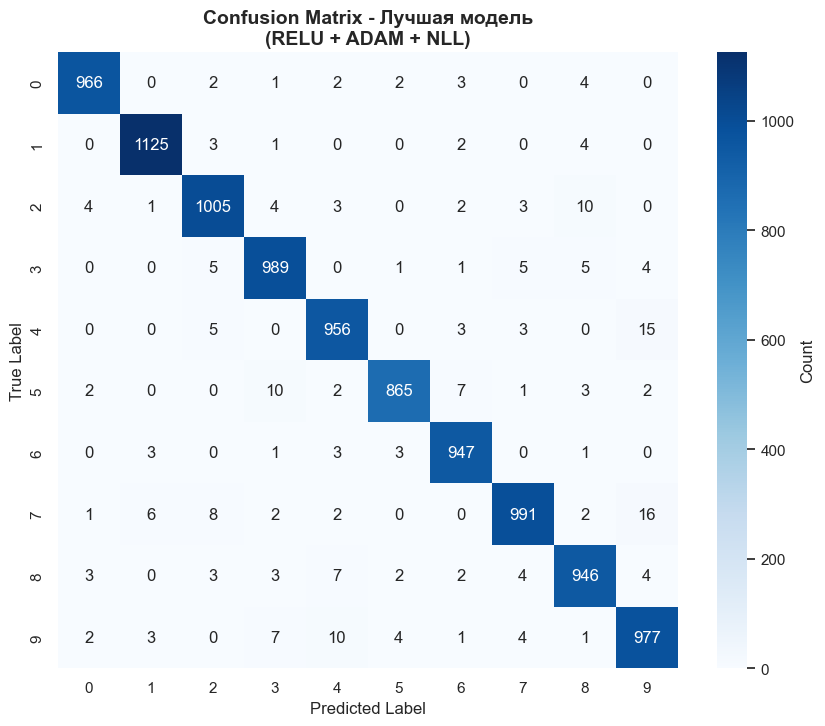

In [65]:
cm = confusion_matrix(best_result['test_labels'], best_result['test_predictions'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
title_text = (f"Confusion Matrix - Лучшая модель\n"
              f"({best_result['activation'].upper()} + {best_result['optimizer'].upper()} + {best_result['loss_function'].upper()})")
plt.title(title_text, fontsize=14, fontweight='bold')
plt.show()

# Выводы по результатам экспериментов

### Общие результаты
сделал **12 тестов** с различными комбинациями:
- **Активации:** ReLU, Sigmoid, Tanh
- **Оптимизаторы:** SGD, Adam
- **Функции потерь:** Cross-Entropy, NLL



### Ключевые наблюдения

Сразу отмечу: я взял 5 эпох обучения, поэтому буду делать выводы по своему эксперименту, не в целом.

- Очень сильно влияет оптимизатор, с 5 эпохами SGD совсем не справляется. Приэтом Adam ведет себя стабильно хорошо. я не уверен в следующем утверждении, был бы рад если бы меня поправили: adam более гибкий как оптимизатор, если мы говорим о коротком, быстром обучении. 

- Функции активации (ReLU, Tanh, sigm) влияют  на результат в меньшей стпени, чем ожидалось. 

- Loss функции также не сильно влияют.

На что я бы обратил внимание:

у нас нет проблемы переобучения: F1-score стабильный на тесте и на обучающей выборке.

In [66]:
print("анализ по оптимизаторам:")
for opt in optimizers_to_test:
    opt_results = [r for r in results if r['optimizer'] == opt]
    avg_acc = np.mean([r['test_accuracy'] for r in opt_results])
    max_acc = np.max([r['test_accuracy'] for r in opt_results])
    min_acc = np.min([r['test_accuracy'] for r in opt_results])
    print(f"\n{opt.upper()}:")
    print(f"  Средняя accuracy: {avg_acc:.4f}")
    print(f"  Максимум: {max_acc:.4f}")
    print(f"  Минимум: {min_acc:.4f}")


print("\nанализ по функциям активации (только с Adam):")


adam_results = [r for r in results if r['optimizer'] == 'adam']
for act in activations_to_test:
    act_results = [r for r in adam_results if r['activation'] == act]
    avg_acc = np.mean([r['test_accuracy'] for r in act_results])
    print(f"{act.upper():10s}: средняя accuracy = {avg_acc:.4f}")


print("\nсравнение CROSS_ENTROPY и NLL:")


for act in activations_to_test:
    for opt in optimizers_to_test:
        ce_result = [r for r in results if r['activation'] == act and r['optimizer'] == opt and r['loss_function'] == 'cross_entropy'][0]
        nll_result = [r for r in results if r['activation'] == act and r['optimizer'] == opt and r['loss_function'] == 'nll'][0]
        diff = abs(ce_result['test_accuracy'] - nll_result['test_accuracy'])
        print(f"{act:8s} + {opt:4s}: разница = {diff:.4f} ({diff*100:.2f}%)")

анализ по оптимизаторам:

SGD:
  Средняя accuracy: 0.4776
  Максимум: 0.7172
  Минимум: 0.1135

ADAM:
  Средняя accuracy: 0.9727
  Максимум: 0.9767
  Минимум: 0.9669

анализ по функциям активации (только с Adam):
RELU      : средняя accuracy = 0.9744
SIGMOID   : средняя accuracy = 0.9678
TANH      : средняя accuracy = 0.9758

сравнение CROSS_ENTROPY и NLL:
relu     + sgd : разница = 0.0548 (5.48%)
relu     + adam: разница = 0.0046 (0.46%)
sigmoid  + sgd : разница = 0.0000 (0.00%)
sigmoid  + adam: разница = 0.0019 (0.19%)
tanh     + sgd : разница = 0.0129 (1.29%)
tanh     + adam: разница = 0.0004 (0.04%)
